# CLAM weekly (v2) — redeveloped after the Signal_Validation review

The quarterly CLAM (`clam_simulation.ipynb`) was reviewed by the independent validation framework in
[Signal_Validation](https://github.com/nahniee/Signal_Validation) and **not approved**. The two findings that
drove the redevelopment:

| finding | what was wrong | fix in `clam_weekly.py` |
|---|---|---|
| F3 (Critical) | training sequences were cut from 94 tickers concatenated and sorted by date — a 252-row window mixed 94 stocks over ~3 days, while inference fed 252 days of one stock | sequences are built **per ticker** (`window_ends` / `make_windows`) |
| F4 (Blocking) | weights trained through 2025-08 → no out-of-time period | training hard-stops at **2021-12-31** (`train_end`); 2022+ is reserved for the validator |

Other changes: horizon 65 → 5 trading days (weekly rebalance), input 252 → 120 days, one scalar target
(next-5-day log return of adjusted close) instead of a 65×5 sequence, top-500 training universe from the
validation database instead of 94 hand-picked large caps, StandardScaler + ±5σ clipping.

Variants trained (all handed to the validator as separate trials):

* `raw` — the 5-day log return itself
* `cs_demeaned` — the 5-day log return minus that week's cross-sectional mean (learn *relative* ranking, not the market)
* `cs_rank_small` — percentile rank within the week as target, smaller network (LSTM 128×2, dropout 0.3)
* a weekly-bar input variant (52 weekly OHLCV bars) collapsed to a constant prediction and was discarded

Nothing after 2021-12-31 is used for any modelling choice. Model selection happens in the validator, and every
variant counts as a trial in its Deflated Sharpe Ratio.

In [1]:
import json, sys
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import clam_weekly as cw
pd.DataFrame({k: [v] for k, v in cw.CONFIG.items() if k not in ("artifacts", "cnn_layers", "lstm_layers")}).T.rename(columns={0: "value"})

I0000 00:00:1789600613.229133  104153 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1789600613.853411  104153 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


,value
seq_length,120
horizon,5
stride,5
train_start,2013-01-01
train_end,2021-12-31
val_years,2
n_tickers,500
dropout,0.2
batch_size,256
epochs,40


## Architecture (unchanged from CLAM: causal Conv1D ×3 → LSTM ×3 → Attention → Dense head)

In [2]:
cw.create_model(cw.CONFIG).summary()

W0000 00:00:1789600614.509198  104153 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 120, 5)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 120, 128)       │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 120, 128)       │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 120, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 120, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 120, 128)       │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 120, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 120, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_2           │ (None, 120, 128)       │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 120, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 120, 256)       │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_3           │ (None, 120, 256)       │           512 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 120, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 120, 256)       │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_4           │ (None, 120, 256)       │           512 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 120, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 120, 256)       │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_5           │ (None, 120, 256)       │           512 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 120, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (Attention)           │ (None, 256)            │           376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fwd_logret (Dense)              │ (None, 1)              │            6

 Total params: 1,631,481 (6.22 MB)

 Trainable params: 1,631,481 (6.22 MB)

 Non-trainable params: 0 (0.00 B)

## Train (or load) both variants

On a GPU each run takes a few minutes. If the artefacts already exist they are loaded instead.

In [3]:
VARIANTS = {
    "raw":         {**cw.CONFIG, "target": "raw"},
    "cs_demeaned": {**cw.CONFIG, "target": "cs_demeaned"},
    "cs_rank_small": {**cw.CONFIG, "target": "cs_rank", "lstm_layers": [{"units": 128}] * 2,
                      "cnn_layers": [{"filters": 64, "kernel_size": 5}] * 2, "dropout": 0.3},
}
results = {}
for name, cfg in VARIANTS.items():
    d = cw.artifact_dir(cfg)
    if not (d / cfg["artifacts"]["meta"]).exists():
        cw.main(cfg)
    results[name] = json.loads((d / cfg["artifacts"]["meta"]).read_text())
pd.DataFrame({t: {"val rank IC": m["val_rank_ic"], "val directional acc": m["val_dir_acc"], "epochs": m["epochs_run"],
                  "train tickers": m["n_tickers"], "val from": m["split"]} for t, m in results.items()}).T

,val rank IC,val directional acc,epochs,train tickers,val from
raw,-0.007549,0.545944,7,478,2019-12-31
cs_demeaned,0.014167,0.502391,10,478,2019-12-31
cs_rank_small,0.01607,0.506015,8,478,2019-12-31


## Training curves

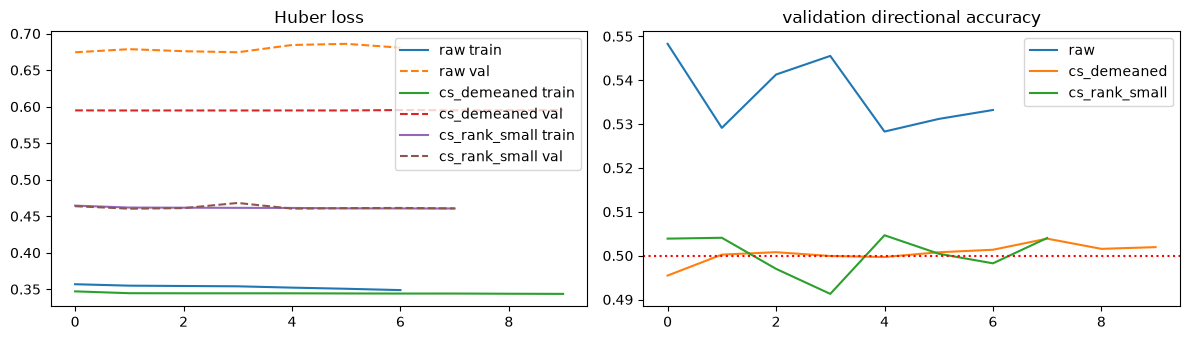

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for t, m in results.items():
    h = m["history"]
    axes[0].plot(h["loss"], label=f"{t} train"); axes[0].plot(h["val_loss"], "--", label=f"{t} val")
    axes[1].plot(h["val_directional_accuracy"], label=t)
axes[0].set_title("Huber loss"); axes[0].legend(); axes[1].set_title("validation directional accuracy"); axes[1].axhline(.5, color="r", ls=":"); axes[1].legend()
plt.tight_layout(); plt.show()

## What the numbers mean

Rank IC is the Spearman correlation between predicted and realised 5-day returns on the 2020-2021 validation
years. For weekly single-stock returns anything above ~0.02 is a usable signal; zero means the network learned
the mean and nothing else. Whether either variant survives out-of-time (2022 →) is decided in
`Signal_Validation/notebooks/05_round2.ipynb`, not here.